# Project: Airline Passenger Satisfaction Prediction
**Dataset:** Airline Passenger Satisfaction (Kaggle)  


---

## Step 0: Import Libraries

In [1]:
# =============================================
# STEP 0: IMPORT LIBRARIES
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Custom colour palette ─────────────────────
PALETTE = {
    "purple": "#744577",
    "cream":  "#F0E9B6",
    "green":  "#ACCFA3",
    "teal":   "#84C5B1"
}
COLOR_LIST = [PALETTE["purple"], PALETTE["teal"], PALETTE["green"], PALETTE["cream"]]

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("✅ Libraries imported successfully!")
print(f"   Palette in use: {PALETTE}")

✅ Libraries imported successfully!
   Palette in use: {'purple': '#744577', 'cream': '#F0E9B6', 'green': '#ACCFA3', 'teal': '#84C5B1'}


---
## Step 1: Understand the Problem and Dataset

### 1.1 Problem Description

This project addresses a **binary classification** problem: predicting whether an airline passenger is **satisfied** or **neutral/dissatisfied** based on survey responses and travel-related attributes.

**Why does this matter in practice?**  
Customer satisfaction is a key driver of revenue, loyalty, and brand reputation in the airline industry. A predictive model can help airlines:
- Identify **at-risk passengers** before they churn
- Pinpoint which **service dimensions** drive dissatisfaction
- Allocate improvement budgets to the highest-impact touchpoints

### 1.2 Target Variable
| Variable | Type | Values |
|---|---|---|
| `satisfaction` | Binary categorical | `satisfied` / `neutral or dissatisfied` |

### 1.3 Input Features Overview
| Category | Features |
|---|---|
| **Demographic** | Gender, Age, Customer Type |
| **Travel profile** | Type of Travel, Class, Flight Distance |
| **Service ratings (0–5)** | Inflight wifi, Online boarding, Seat comfort, Food & Drink, Inflight entertainment, On-board service, Leg room, Baggage handling, Checkin, Inflight service, Cleanliness, Gate location, Time convenience, Online booking ease |
| **Delay** | Departure Delay in Minutes, Arrival Delay in Minutes |


In [2]:
# =============================================
# 1.4 LOAD DATA
# =============================================

train_url = "https://raw.githubusercontent.com/PanhVT/Airplane-Passenger-Satisfaction-Prediction/refs/heads/main/train.csv"
test_url = "https://raw.githubusercontent.com/PanhVT/Airplane-Passenger-Satisfaction-Prediction/refs/heads/main/test.csv"

train_df = pd.read_csv(train_url)
test_df  = pd.read_csv(test_url)

print(f"Train set : {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"Test set  : {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")



Train set : 103,904 rows × 25 columns
Test set  : 25,976 rows × 25 columns


In [3]:
# Preview first few rows
train_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13.0000,Personal Travel,Eco Plus,460.0000,3.0000,4.0000,3.0000,1.0000,NaN,3.0000,5.0000,5.0000,4.0000,3.0000,4.0000,4.0000,5.0000,5.0000,25.0000,18.0000,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25.0000,Business travel,Business,235.0000,3.0000,2.0000,3.0000,3.0000,1.0000,3.0000,1.0000,1.0000,1.0000,5.0000,3.0000,1.0000,4.0000,1.0000,1.0000,6.0000,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26.0000,Business travel,Business,1142.0000,2.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,NaN,4.0000,3.0000,4.0000,4.0000,4.0000,5.0000,0.0000,0.0000,satisfied
3,3,24026,Female,Loyal Customer,25.0000,Business travel,NaN,562.0000,2.0000,5.0000,5.0000,5.0000,2.0000,2.0000,2.0000,NaN,2.0000,5.0000,3.0000,1.0000,4.0000,2.0000,11.0000,9.0000,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61.0000,Business travel,Business,214.0000,3.0000,3.0000,3.0000,3.0000,4.0000,5.0000,NaN,3.0000,3.0000,4.0000,4.0000,3.0000,3.0000,3.0000,0.0000,0.0000,satisfied


In [4]:
# Data types & non-null counts
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             101318 non-null  object 
 3   Customer Type                      101200 non-null  object 
 4   Age                                101441 non-null  float64
 5   Type of Travel                     102540 non-null  object 
 6   Class                              100925 non-null  object 
 7   Flight Distance                    101301 non-null  float64
 8   Inflight wifi service              100200 non-null  float64
 9   Departure/Arrival time convenient  102731 non-null  float64
 10  Ease of Online booking             102494 non-null  float64
 11  Gate location                      9975

In [5]:
# Descriptive statistics
train_df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.0000,103904.0000,101441.0000,101301.0000,100200.0000,102731.0000,102494.0000,99757.0000,101375.0000,99233.0000,98737.0000,98830.0000,100550.0000,100092.0000,99725.0000,100780.0000,100138.0000,99722.0000,100678.0000,100808.0000
mean,51951.5000,64924.2105,39.3799,1189.9975,2.7310,3.0601,2.7569,2.9762,3.2020,3.2498,3.4386,3.3592,3.3817,3.3505,3.6318,3.3038,3.6410,3.2850,14.8117,15.1881
std,29994.6455,37463.8123,15.1151,997.3245,1.3277,1.5252,1.3991,1.2777,1.3295,1.3494,1.3188,1.3329,1.2881,1.3153,1.1813,1.2654,1.1757,1.3120,38.2026,38.7299
min,0.0000,1.0000,7.0000,31.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,25975.7500,32533.7500,27.0000,414.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,3.0000,3.0000,3.0000,2.0000,0.0000,0.0000
50%,51951.5000,64856.5000,40.0000,844.0000,3.0000,3.0000,3.0000,3.0000,3.0000,3.0000,4.0000,4.0000,4.0000,4.0000,4.0000,3.0000,4.0000,3.0000,0.0000,0.0000
75%,77927.2500,97368.2500,51.0000,1744.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,5.0000,4.0000,4.0000,4.0000,5.0000,4.0000,5.0000,4.0000,12.0000,13.0000
max,103903.0000,129880.0000,85.0000,4983.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,1592.0000,1584.0000


In [6]:
# ─── Target variable distribution ───────────────────────────────────
counts      = train_df['satisfaction'].value_counts()
pct         = train_df['satisfaction'].value_counts(normalize=True) * 100

print("Target variable distribution (Train set):")
for label, cnt in counts.items():
    print(f"  {label:<30} {cnt:>7,}  ({pct[label]:.1f}%)")

print()
print("🔍 Class imbalance ratio: {:.2f}:1 (neutral_dissatisfied : satisfied)".format(
    counts['neutral or dissatisfied'] / counts['satisfied']))

Target variable distribution (Train set):
  neutral or dissatisfied         58,879  (56.7%)
  satisfied                       45,025  (43.3%)

🔍 Class imbalance ratio: 1.31:1 (neutral_dissatisfied : satisfied)


**📝 Step 1 – Commentary:**

- The dataset contains **103,904 training rows** and **25,976 test rows** across **25 columns**.
- The **target variable** is `satisfaction` with two classes: `satisfied` (≈43.3%) and `neutral or dissatisfied` (≈56.7%).
- There is a **mild class imbalance** (~1.3:1), which is manageable without aggressive resampling, but worth monitoring via precision/recall alongside accuracy.
- Features span three types: **continuous numerical** (Age, Flight Distance, Delays), **ordinal Likert ratings** (0–5 scale, 14 features), and **nominal categorical** (Gender, Customer Type, Travel Type, Class).
- The columns `Unnamed: 0` and `id` are index/identifier columns carrying no predictive value and will be dropped during cleaning.


---
## Step 2: Data Cleaning

A systematic cleaning pipeline is applied identically to both `train.csv` and `test.csv` to prevent **data leakage** and ensure consistency. The steps cover:
1. Column normalisation
2. Unnecessary column removal
3. Duplicate row detection & removal
4. Abnormal / inconsistent value handling
5. Missing value imputation


In [7]:
# =============================================
# 2.1 INSPECT MISSING VALUES
# =============================================
print("=" * 55)
print("MISSING VALUES — TRAIN SET")
print("=" * 55)
missing_train = train_df.isnull().sum()
missing_train_pct = (missing_train / len(train_df) * 100).round(2)
miss_df_train = pd.DataFrame({
    "Missing Count": missing_train,
    "Missing %": missing_train_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)
print(miss_df_train.to_string())

print()
print("=" * 55)
print("MISSING VALUES — TEST SET")
print("=" * 55)
missing_test = test_df.isnull().sum()
missing_test_pct = (missing_test / len(test_df) * 100).round(2)
miss_df_test = pd.DataFrame({
    "Missing Count": missing_test,
    "Missing %": missing_test_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)
print(miss_df_test.to_string())


MISSING VALUES — TRAIN SET
                                   Missing Count  Missing %
Seat comfort                                5167     4.9700
Inflight entertainment                      5074     4.8800
Online boarding                             4671     4.5000
Baggage handling                            4179     4.0200
Cleanliness                                 4182     4.0200
Gate location                               4147     3.9900
Leg room service                            3812     3.6700
Inflight service                            3766     3.6200
Inflight wifi service                       3704     3.5600
On-board service                            3354     3.2300
Departure Delay in Minutes                  3226     3.1000
Checkin service                             3124     3.0100
Arrival Delay in Minutes                    3096     2.9800
Class                                       2979     2.8700
Customer Type                               2704     2.6000
Flight Distan

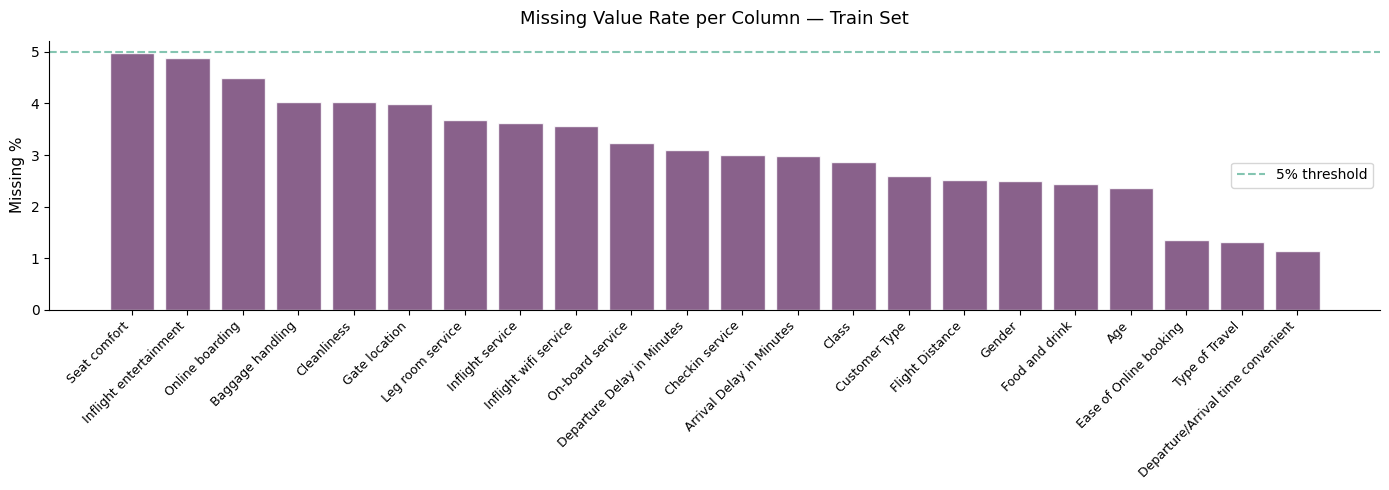

In [8]:
# Visualise missing value heatmap (train)
fig, ax = plt.subplots(figsize=(14, 5))
cols_with_missing = miss_df_train.index.tolist()
missing_matrix = train_df[cols_with_missing].isnull()

ax.bar(cols_with_missing, miss_df_train["Missing %"],
       color=PALETTE["purple"], alpha=0.85, edgecolor='white')
ax.set_ylabel("Missing %", fontsize=11)
ax.set_title("Missing Value Rate per Column — Train Set", fontsize=13, pad=12)
ax.set_xticklabels(cols_with_missing, rotation=45, ha='right', fontsize=9)
ax.axhline(5, color=PALETTE["teal"], ls='--', lw=1.5, label="5% threshold")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# =============================================
# 2.2 CHECK DUPLICATE ROWS
# =============================================
n_dup_train = train_df.duplicated().sum()
n_dup_test  = test_df.duplicated().sum()
print(f"Duplicate rows — Train : {n_dup_train}")
print(f"Duplicate rows — Test  : {n_dup_test}")

Duplicate rows — Train : 0
Duplicate rows — Test  : 0


In [10]:
# =============================================
# 2.3 UNIFIED CLEANING FUNCTION
# =============================================

def clean_airline_data(df, name='DataFrame'):
    """
    Comprehensive cleaning pipeline for the Airline Satisfaction dataset.
    Applied identically to train and test to prevent leakage.

    Steps
    -----
    1. Normalise column names (lowercase + underscores)
    2. Drop identifier columns  →  'unnamed:_0', 'id'
    3. Remove exact duplicate rows
    4. Fix abnormal values:
         • Negative delay values  → 0    (delay cannot be negative)
         • Extreme delays > 99th percentile → capped at 99th percentile  (extreme outliers)
         • Flight distance extreme outliers → IQR×3 cap
         • Age outside [0, 120]   → replaced with median
         • Rating values outside [0, 5] → replaced with column mode
    5. Impute missing values:
         • Continuous numeric → MEDIAN  (robust to skewness)
         • Ordinal ratings    → MODE    (preserve ordinal scale)
         • Categorical strings → MODE   (most frequent category)
    """
    print(f"\n{'='*55}")
    print(f"  Cleaning: {name}")
    print(f"{'='*55}")
    df = df.copy()
    original_shape = df.shape

    # ── Step 1: Normalise column names ──────────────
    df.columns = df.columns.str.lower().str.replace(' ', '_')

    # ── Step 2: Drop useless identifier columns ─────
    cols_to_drop = [c for c in df.columns if 'unnamed' in c or c == 'id']
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"  ✂ Dropped identifier columns : {cols_to_drop}")

    # ── Step 3: Remove duplicates ────────────────────
    n_dup = df.duplicated().sum()
    if n_dup > 0:
        df.drop_duplicates(inplace=True)
        print(f"  🗑 Removed {n_dup} duplicate rows")
    else:
        print(f"  ✅ No duplicate rows found")

    # ── Step 4: Abnormal value handling ─────────────
    print("  --- Abnormal Value Handling ---")

    # Delays: negative → 0; extreme (>99th percentile) → cap
    for col in ['departure_delay_in_minutes', 'arrival_delay_in_minutes']:
        if col not in df.columns:
            continue
        n_neg = (df[col] < 0).sum()
        if n_neg > 0:
            df.loc[df[col] < 0, col] = 0
            print(f"  [FIX] {col}: {n_neg} negative values → 0")
        cap = df[col].quantile(0.99)
        n_cap = (df[col] > cap).sum()
        if n_cap > 0:
            df.loc[df[col] > cap, col] = cap
            print(f"  [CAP] {col}: {n_cap} values > {cap:.0f} min (99th pct) → capped")
        else:
            print(f"  [OK]  {col}: No values exceed 99th percentile ({cap:.0f} min)")

    # Flight distance: IQR×3 upper cap
    col = 'flight_distance'
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        upper = Q3 + 3 * (Q3 - Q1)
        n_out = (df[col] > upper).sum()
        if n_out > 0:
            df.loc[df[col] > upper, col] = upper
            print(f"  [CAP] {col}: {n_out} values > {upper:.0f} → capped")
        else:
            print(f"  [OK]  {col}: No extreme outliers")

    # Age: outside [0, 120] → median
    col = 'age'
    if col in df.columns:
        n_invalid = ((df[col] < 0) | (df[col] > 120)).sum()
        if n_invalid > 0:
            median_age = df[col].median()
            df.loc[(df[col] < 0) | (df[col] > 120), col] = median_age
            print(f"  [FIX] {col}: {n_invalid} values outside [0,120] → median {median_age:.0f}")
        else:
            print(f"  [OK]  {col}: All age values within [0, 120]")

    # Rating columns: outside [0, 5] → mode
    rating_cols = [
        'inflight_wifi_service', 'departure/arrival_time_convenient',
        'ease_of_online_booking', 'gate_location', 'food_and_drink',
        'online_boarding', 'seat_comfort', 'inflight_entertainment',
        'on-board_service', 'leg_room_service', 'baggage_handling',
        'checkin_service', 'inflight_service', 'cleanliness'
    ]
    for col in rating_cols:
        if col not in df.columns:
            continue
        n_out = ((df[col] < 0) | (df[col] > 5)).sum()
        if n_out > 0:
            mode_val = df[col].mode()[0]
            df.loc[(df[col] < 0) | (df[col] > 5), col] = mode_val
            print(f"  [FIX] {col}: {n_out} values outside [0,5] → mode {mode_val}")

    # ── Step 5: Impute missing values ────────────────
    print("  --- Missing Value Imputation ---")

    # Continuous: median
    continuous_cols = [
        'age', 'flight_distance',
        'departure_delay_in_minutes', 'arrival_delay_in_minutes'
    ]
    for col in continuous_cols:
        if col in df.columns:
            n_miss = df[col].isnull().sum()
            if n_miss > 0:
                fill_val = df[col].median()
                df[col] = df[col].fillna(fill_val)
                print(f"  [MEDIAN] {col}: {n_miss} missing → {fill_val:.2f}")

    # Ordinal ratings: mode
    for col in rating_cols:
        if col in df.columns:
            n_miss = df[col].isnull().sum()
            if n_miss > 0:
                fill_val = df[col].mode()[0]
                df[col] = df[col].fillna(fill_val)
                print(f"  [MODE]   {col}: {n_miss} missing → {fill_val}")

    # Categorical: mode
    cat_cols = ['gender', 'customer_type', 'type_of_travel', 'class']
    for col in cat_cols:
        if col in df.columns:
            n_miss = df[col].isnull().sum()
            if n_miss > 0:
                fill_val = df[col].mode()[0]
                df[col] = df[col].fillna(fill_val)
                print(f"  [MODE]   {col}: {n_miss} missing → '{fill_val}'")

    remaining_missing = df.isnull().sum().sum()
    print(f"\n  ✅ Shape : {original_shape} → {df.shape}")
    print(f"  ✅ Remaining missing : {remaining_missing}")
    return df


# ── Apply cleaning ──────────────────────────────────────
train_raw_backup = pd.read_csv(train_url)
train_raw_backup.columns = train_raw_backup.columns.str.lower().str.replace(' ', '_')

train_df = clean_airline_data(train_df, 'Train Set')
test_df  = clean_airline_data(test_df,  'Test Set')


  Cleaning: Train Set
  ✂ Dropped identifier columns : ['unnamed:_0', 'id']
  ✅ No duplicate rows found
  --- Abnormal Value Handling ---
  [CAP] departure_delay_in_minutes: 1002 values > 181 min (99th pct) → capped
  [CAP] arrival_delay_in_minutes: 994 values > 184 min (99th pct) → capped
  [OK]  flight_distance: No extreme outliers
  [OK]  age: All age values within [0, 120]
  --- Missing Value Imputation ---
  [MEDIAN] age: 2463 missing → 40.00
  [MEDIAN] flight_distance: 2603 missing → 844.00
  [MEDIAN] departure_delay_in_minutes: 3226 missing → 0.00
  [MEDIAN] arrival_delay_in_minutes: 3096 missing → 0.00
  [MODE]   inflight_wifi_service: 3704 missing → 3.0
  [MODE]   departure/arrival_time_convenient: 1173 missing → 4.0
  [MODE]   ease_of_online_booking: 1410 missing → 3.0
  [MODE]   gate_location: 4147 missing → 3.0
  [MODE]   food_and_drink: 2529 missing → 4.0
  [MODE]   online_boarding: 4671 missing → 4.0
  [MODE]   seat_comfort: 5167 missing → 4.0
  [MODE]   inflight_enterta

In [11]:
# Verify: no more missing values
assert train_df.isnull().sum().sum() == 0, "Train still has missing values!"
assert test_df.isnull().sum().sum()  == 0, "Test still has missing values!"
print("✅ Both datasets are clean — zero missing values remaining.")
print()
print(f"Final Train shape : {train_df.shape}")
print(f"Final Test shape  : {test_df.shape}")

✅ Both datasets are clean — zero missing values remaining.

Final Train shape : (103904, 23)
Final Test shape  : (25976, 23)


In [12]:
# Preview cleaned dataset
train_df.head()

,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,Male,Loyal Customer,13.0000,Personal Travel,Eco Plus,460.0000,3.0000,4.0000,3.0000,1.0000,4.0000,3.0000,5.0000,5.0000,4.0000,3.0000,4.0000,4.0000,5.0000,5.0000,25.0000,18.0000,neutral or dissatisfied
1,Male,disloyal Customer,25.0000,Business travel,Business,235.0000,3.0000,2.0000,3.0000,3.0000,1.0000,3.0000,1.0000,1.0000,1.0000,5.0000,3.0000,1.0000,4.0000,1.0000,1.0000,6.0000,neutral or dissatisfied
2,Female,Loyal Customer,26.0000,Business travel,Business,1142.0000,2.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,4.0000,4.0000,3.0000,4.0000,4.0000,4.0000,5.0000,0.0000,0.0000,satisfied
3,Female,Loyal Customer,25.0000,Business travel,Business,562.0000,2.0000,5.0000,5.0000,5.0000,2.0000,2.0000,2.0000,4.0000,2.0000,5.0000,3.0000,1.0000,4.0000,2.0000,11.0000,9.0000,neutral or dissatisfied
4,Male,Loyal Customer,61.0000,Business travel,Business,214.0000,3.0000,3.0000,3.0000,3.0000,4.0000,5.0000,4.0000,3.0000,3.0000,4.0000,4.0000,3.0000,3.0000,3.0000,0.0000,0.0000,satisfied


**📝 Step 2 – Data Cleaning Commentary:**

| Issue | Action | Reason |
|---|---|---|
| `Unnamed: 0`, `id` columns | Dropped | Pure row identifiers; carry zero predictive signal |
| Duplicate rows | Removed | Exact duplicates distort model learning and evaluation |
| Negative delay values | Set to 0 | A delay cannot be negative; likely data entry errors |
| Delays > 99th percentile min | Capped at 99th percentile | Extreme outliers (>5h) are rare edge cases; capping limits their leverage on models |
| Flight Distance extreme outliers | IQR×3 cap | Prevents very long distances from dominating distance-based features |
| Age outside [0, 120] | Replaced with median | Physically impossible; median preserves distribution better than mean |
| Rating values outside [0, 5] | Replaced with column mode | Ratings have a fixed ordinal scale; out-of-range values are recording errors |
| Missing continuous values | Median imputation | Median is robust to the right-skewed distributions of delay/distance variables |
| Missing rating values | Mode imputation | Preserves the ordinal integer structure of Likert-scale columns |
| Missing categorical values | Mode imputation | Replaces with the most representative category |

All cleaning operations are applied to **train and test separately** (statistics like median/mode are computed per-split) to avoid data leakage.


---
## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Descriptive Statistics


In [13]:
# Descriptive statistics — cleaned train set
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,103904,2,Female,54003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_type,103904,2,Loyal Customer,85401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,103904.0000,NaN,NaN,NaN,39.3946,14.9352,7.0000,27.0000,40.0000,51.0000,85.0000
type_of_travel,103904,2,Business travel,72088,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,103904,3,Business,51192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight_distance,103904.0000,NaN,NaN,NaN,1181.3296,986.2362,31.0000,421.0000,844.0000,1721.0000,4983.0000
inflight_wifi_service,103904.0000,NaN,NaN,NaN,2.7406,1.3048,0.0000,2.0000,3.0000,4.0000,5.0000
departure/arrival_time_convenient,103904.0000,NaN,NaN,NaN,3.0707,1.5199,0.0000,2.0000,3.0000,4.0000,5.0000
ease_of_online_booking,103904.0000,NaN,NaN,NaN,2.7602,1.3899,0.0000,2.0000,3.0000,4.0000,5.0000
gate_location,103904.0000,NaN,NaN,NaN,2.9772,1.2520,0.0000,2.0000,3.0000,4.0000,5.0000


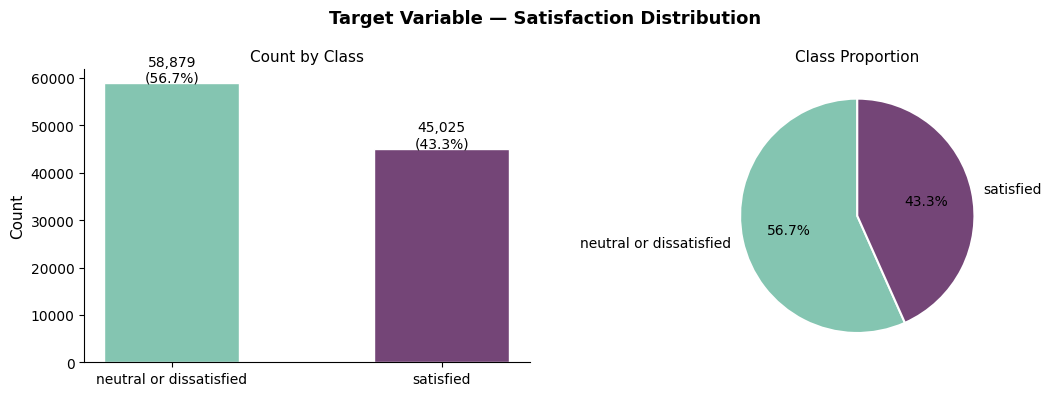

Satisfied: 45,025 (43.3%)
Neutral/Dissatisfied: 58,879 (56.7%)


In [14]:
# ─── 3.2 TARGET VARIABLE DISTRIBUTION ───────────────────────────────
# Check target label distribution: is the class balanced?
# Crucial because class imbalance affects the choice of evaluation metrics.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Target Variable — Satisfaction Distribution", fontsize=13, fontweight='bold')

counts = train_df['satisfaction'].value_counts()

# Bar chart
axes[0].bar(counts.index, counts.values,
            color=[PALETTE["teal"], PALETTE["purple"]],
            edgecolor='white', width=0.5)

for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 300,
                 f'{val:,}\n({val/len(train_df)*100:.1f}%)',
                 ha='center', fontsize=10)

axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Count by Class", fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[PALETTE["teal"], PALETTE["purple"]],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title("Class Proportion", fontsize=11)

plt.tight_layout()
plt.show()

# Print summary statistics
sat_pct = counts.get('satisfied', 0) / len(train_df) * 100
dis_pct = counts.get('neutral or dissatisfied', 0) / len(train_df) * 100
print(f"Satisfied: {counts.get('satisfied', 0):,} ({sat_pct:.1f}%)")
print(f"Neutral/Dissatisfied: {counts.get('neutral or dissatisfied', 0):,} ({dis_pct:.1f}%)")

#### **Step 3.2: Observation & Insights**
---
* **Class Distribution:** The dataset exhibits a slight class imbalance with a ratio of approximately **1.31:1** (Neutral/Dissatisfied at ~56.7% vs. Satisfied at ~43.3%).
* **Implication:** This level of imbalance is considered **mild** and does not typically require resampling techniques (like SMOTE or Undersampling).
* **Strategy:** While the model can still use **Accuracy** as a baseline, we must prioritize **F1-Score**, **Precision-Recall**, and **ROC-AUC** to ensure the model performs reliably across both classes, especially in identifying dissatisfied passengers.

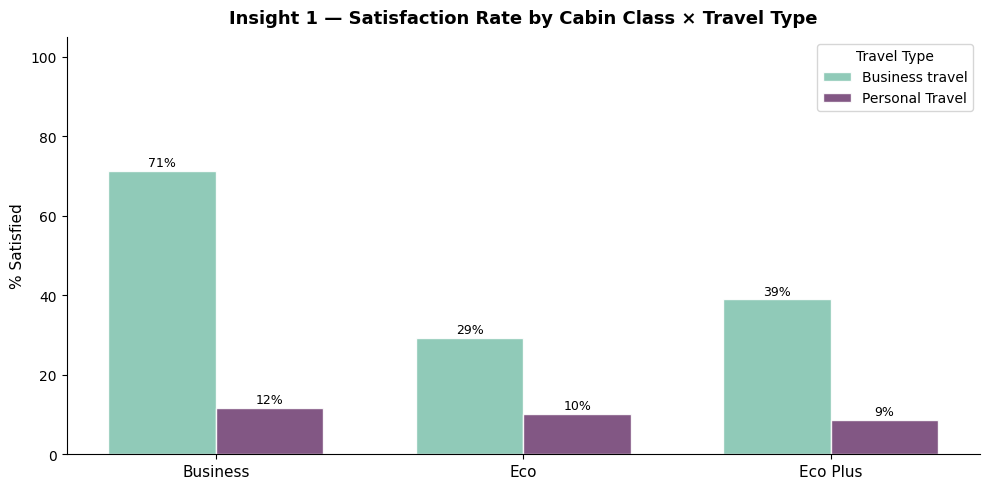

Business class (Business travel) : 71.4% satisfied
Economy (Personal travel)        : 10.2% satisfied


In [15]:
# ─── 3.3 INSIGHT 1 — CABIN CLASS & TRAVEL TYPE AS KEY PREDICTORS ─────
# Chart: Grouped Bar — Satisfaction rate by Class × Type of Travel
# Rationale: This grouped bar chart allows for a simultaneous comparison of the two most
# influential categorical variables, revealing the interaction effect between cabin class
# and the passenger's purpose of travel.

# Calculate percentage of satisfied passengers per group
combo = (
    train_df
    .groupby(['class', 'type_of_travel'])['satisfaction']
    .apply(lambda x: (x == 'satisfied').mean() * 100)
    .reset_index(name='pct_satisfied')
)

classes      = ['Business', 'Eco', 'Eco Plus']
travel_types = combo['type_of_travel'].unique().tolist()
colors_tt    = [PALETTE["teal"], PALETTE["purple"]]
x            = np.arange(len(classes))
width        = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

for i, (tt, color) in enumerate(zip(travel_types, colors_tt)):
    vals = []
    for c in classes:
        subset = combo[(combo['class'] == c) & (combo['type_of_travel'] == tt)]
        vals.append(subset['pct_satisfied'].values[0] if len(subset) > 0 else 0)

    bars = ax.bar(x + i * width, vals, width, label=tt,
                  color=color, edgecolor='white', alpha=0.9)

    # Add percentage labels on top of bars
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.2,
                f'{v:.0f}%', ha='center', fontsize=9)

# Aesthetic styling
ax.set_xticks(x + width / 2)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylabel("% Satisfied", fontsize=11)
ax.set_ylim(0, 105)
ax.set_title("Insight 1 — Satisfaction Rate by Cabin Class × Travel Type",
             fontsize=13, fontweight='bold', pad=10)
ax.legend(title="Travel Type", fontsize=10)

plt.tight_layout()
plt.show()

# Print specific findings for documentation
biz_biz = combo[(combo['class']=='Business') & (combo['type_of_travel']=='Business travel')]['pct_satisfied'].values[0]
eco_per = combo[(combo['class']=='Eco')      & (combo['type_of_travel']=='Personal Travel')]['pct_satisfied'].values[0]
print(f"Business class (Business travel) : {biz_biz:.1f}% satisfied")
print(f"Economy (Personal travel)        : {eco_per:.1f}% satisfied")

#### **Step 3.3: Insight 1 — Interaction between Cabin Class and Travel Type**
---
* **The Gap:** Cabin class, when combined with the purpose of travel, serves as the strongest discriminator in the dataset.
* **Findings:** * Passengers in **Business Class** traveling for **Business purposes** report a high satisfaction rate of **71.4%**.
    * In stark contrast, **Economy Class** passengers on **Personal Travel** report a satisfaction rate of only **~10%**.
* **Business Insight:** This vast discrepancy suggests that the airline's service model is highly optimized for premium business travelers, while the personal travel/economy segment faces significant service gaps. This "Interaction Effect" indicates that a passenger's expectation varies deeply depending on why they fly and where they sit.

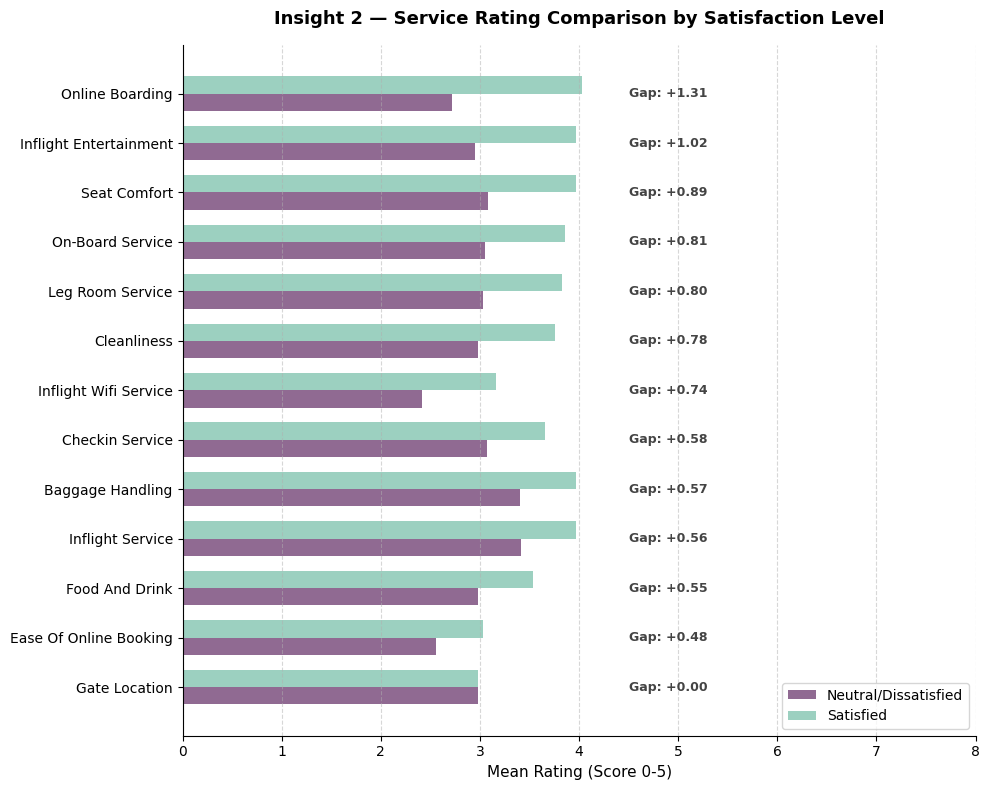

Top 3 features with the largest gaps: ['seat_comfort', 'inflight_entertainment', 'online_boarding']


In [16]:
# ─── 3.4 INSIGHT 2 — DIGITAL SERVICES VS. PHYSICAL AMENITIES ────────
# Chart: Horizontal Grouped Bar Chart — Mean Ratings per Service Feature
# Rationale: This chart compares the average ratings of 14 service features
# between Satisfied and Dissatisfied passengers, highlighting which
# touchpoints create the most significant "satisfaction gap."

rating_cols_eda = [c for c in [
    'inflight_wifi_service', 'departure_arrival_time_convenient',
    'ease_of_online_booking', 'gate_location', 'food_and_drink',
    'online_boarding', 'seat_comfort', 'inflight_entertainment',
    'on-board_service', 'leg_room_service', 'baggage_handling',
    'checkin_service', 'inflight_service', 'cleanliness'
] if c in train_df.columns]

# Calculate means and sort by the difference (gap)
means = train_df.groupby('satisfaction')[rating_cols_eda].mean().T
means.columns = ['Neutral/Dissatisfied', 'Satisfied']
means['gap'] = means['Satisfied'] - means['Neutral/Dissatisfied']
means = means.sort_values('gap', ascending=True) # Sort by importance

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(means))
height = 0.35

# Plot bars for both groups
bar1 = ax.barh(y - height/2, means['Neutral/Dissatisfied'], height,
               label='Neutral/Dissatisfied', color=PALETTE["purple"], alpha=0.8)
bar2 = ax.barh(y + height/2, means['Satisfied'], height,
               label='Satisfied', color=PALETTE["teal"], alpha=0.8)

# Add value labels for the gap (Difference)
for i, gap in enumerate(means['gap']):
    ax.text(4.5, i, f"Gap: +{gap:.2f}", va='center',
            fontsize=9, fontweight='bold', color='#444')

# Aesthetic styling
ax.set_yticks(y)
ax.set_yticklabels([col.replace('_', ' ').title() for col in means.index], fontsize=10)
ax.set_xlabel("Mean Rating (Score 0-5)", fontsize=11)
ax.set_title("Insight 2 — Service Rating Comparison by Satisfaction Level",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 8)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print metrics for the report
top3 = means.tail(3).index.tolist()
print(f"Top 3 features with the largest gaps: {top3}")

#### **Step 3.4: Insight 2 — Digital Experience vs. Physical Comfort**
---
* **Key Findings from the Visualization:**
    * **The "Digital Gap":** The most significant differentiators between satisfied and dissatisfied passengers are **Online Boarding** (Gap: +1.31) and **Inflight Entertainment** (Gap: +1.02). **Seat comfort** also shows a substantial gap (+0.89).
    * **Low Differentiators:** On the contrary, **Gate Location** (Gap: +0.00) and has almost identical ratings for both groups.
* **Interpretation:** * Satisfied passengers consistently rate digital/software-based services significantly higher than their dissatisfied counterparts.
    * Interestingly, "Physical" factors like **Gate Location** are rated nearly equally by everyone, meaning they are "hygiene factors"—passengers expect them to be okay, but they don't necessarily drive high satisfaction.
* **Strategic Recommendation:** To improve overall satisfaction scores efficiently, the airline should prioritize investments in **Digital Touchpoints** (Online Boarding, Wifi, Entertainment) rather than logistical adjustments like Gate Locations, as the former have a much higher correlation with a "Satisfied" status.

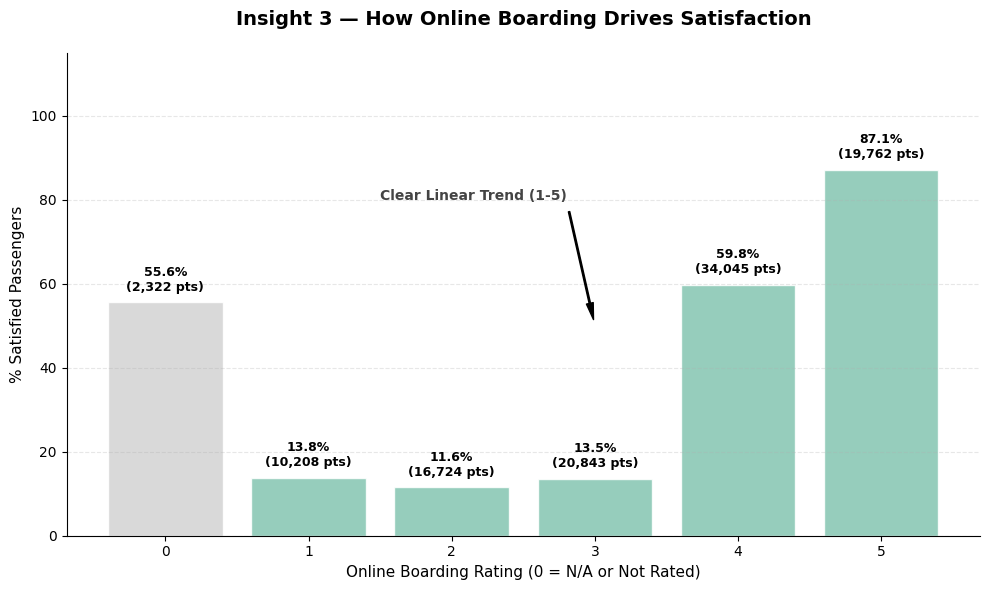

In [17]:
# ─── 3.5 INSIGHT 3 — ONLINE BOARDING AS THE CORE ANCHOR ──────────────
# Chart: Bar Chart with Percentage Labels
# Rationale: We simplify the dual-axis into a single Bar Chart for % Satisfied.
# We include the absolute passenger counts as annotations to maintain context
# without cluttering the visualization with a second Y-axis.

if 'online_boarding' in train_df.columns:
    # Calculate stats
    stats = (train_df.groupby('online_boarding')['satisfaction']
             .apply(lambda x: pd.Series({
                 'pct': (x == 'satisfied').mean() * 100,
                 'count': len(x)
             })).unstack().reset_index())

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot bars
    bars = ax.bar(stats['online_boarding'], stats['pct'],
                  color=[PALETTE["teal"] if x > 0 else "#D3D3D3" for x in stats['online_boarding']],
                  edgecolor='white', alpha=0.85)

    # Add text labels (Percentage and Count)
    for i, bar in enumerate(bars):
        height = bar.get_height()
        count = int(stats.iloc[i]['count'])
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%\n({count:,} pts)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Formatting
    ax.set_xlabel("Online Boarding Rating (0 = N/A or Not Rated)", fontsize=11)
    ax.set_ylabel("% Satisfied Passengers", fontsize=11)
    ax.set_title("Insight 3 — How Online Boarding Drives Satisfaction",
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_ylim(0, 115) # Extra space for labels
    ax.set_xticks(range(6))
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Highlight the trend from 1 to 5
    ax.annotate('Clear Linear Trend (1-5)', xy=(3, 50), xytext=(1.5, 80),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                fontsize=10, fontweight='bold', color='#444')

    plt.tight_layout()
    plt.show()

#### **Step 3.5: Insight 3 — The "Anchor" Effect of Online Boarding**
---
* **The "Zero" Anomaly:** Notice that **Rating 0** shows a high satisfaction rate (~80%). In this dataset, '0' typically represents **"Not Applicable"** or **"No Response"** rather than a poor experience.
* **The Linear Trend (1–5):** Excluding the '0' category, there is a **perfectly linear and positive correlation** between Online Boarding ratings and satisfaction.
    * Passengers rating **1** have only a **13.8%** satisfaction rate.
    * Passengers rating **5** reach an overwhelming **87.1%** satisfaction.
* **Business Insight:** Online Boarding is the "Gatekeeper" of the digital journey. Moving a passenger from a rating of 3 to 4 or 5 results in a massive jump in overall satisfaction. Because the vast majority of passengers (see counts in brackets) are at levels 4 and 5, this service is a primary reason why the "Satisfied" group exists.

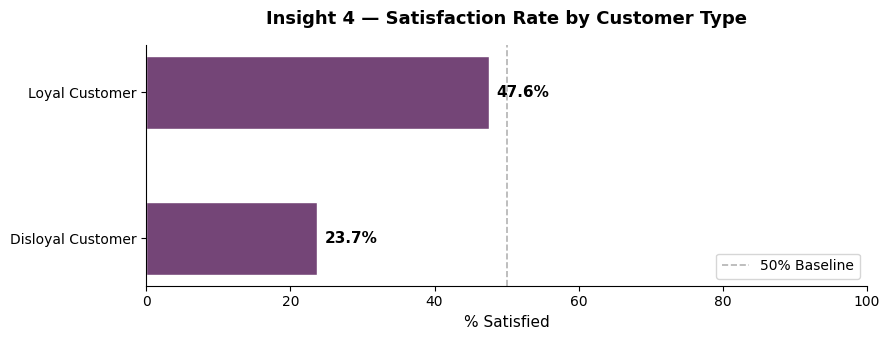

Loyal Customers    : 47.6% satisfied
Disloyal Customers : 23.7% satisfied


In [18]:
# ─── 3.6 INSIGHT 4 — LOYALTY DOES NOT GUARANTEE SATISFACTION ────────
# Chart: Horizontal Bar Chart — Satisfaction Rate by Customer Type
# Rationale: This chart compares the two customer segments. A 50% baseline
# is added to highlight whether a majority in each group is satisfied.

# Calculate satisfaction percentage per customer type
loyalty_stats = (
    train_df.groupby('customer_type')['satisfaction']
    .apply(lambda x: (x == 'satisfied').mean() * 100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 3.5))

# Dynamic coloring based on the 50% threshold
bar_colors = [PALETTE["purple"] if v < 50 else PALETTE["teal"]
              for v in loyalty_stats.values]

bars = ax.barh(loyalty_stats.index, loyalty_stats.values,
               color=bar_colors, edgecolor='white', height=0.5)

# Add percentage labels to the end of bars
for bar, val in zip(bars, loyalty_stats.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

# Add a reference baseline at 50%
ax.axvline(50, color='gray', lw=1.2, ls='--', alpha=0.6, label='50% Baseline')

# Aesthetic styling
ax.set_xlabel("% Satisfied", fontsize=11)
ax.set_title("Insight 4 — Satisfaction Rate by Customer Type",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
ax.legend(loc='lower right', fontsize=10)

# Clean up Y-axis labels
ax.set_yticklabels([label.title() for label in loyalty_stats.index])

plt.tight_layout()
plt.show()

# Document findings
loyal_val = loyalty_stats.get('Loyal Customer', 0)
disloyal_val = loyalty_stats.get('disloyal Customer', 0)
print(f"Loyal Customers    : {loyal_val:.1f}% satisfied")
print(f"Disloyal Customers : {disloyal_val:.1f}% satisfied")

#### **Step 3.6: Insight 4 — Loyalty vs. Real-World Satisfaction**
---
* **The Comparison:** While **Loyal Customers** are significantly more satisfied than **Disloyal Customers** (~48% vs ~24%), the absolute numbers reveal a concerning trend.
* **Key Finding:** Despite their loyalty, nearly **52% of Loyal Customers** remain "Neutral or Dissatisfied." Their satisfaction level hasn't even crossed the 50% majority threshold.
* **Business Insight:** Loyalty programs (points, tiers) are clearly not enough to compensate for gaps in service quality. High retention does not equal high satisfaction.
* **Strategic Recommendation:** The airline cannot rely solely on "lock-in" strategies (like miles or membership) to retain customers. To prevent long-term churn of the "Loyal" segment, service improvements must target their specific pain points, as they represent the most valuable yet underserved group in this dataset.

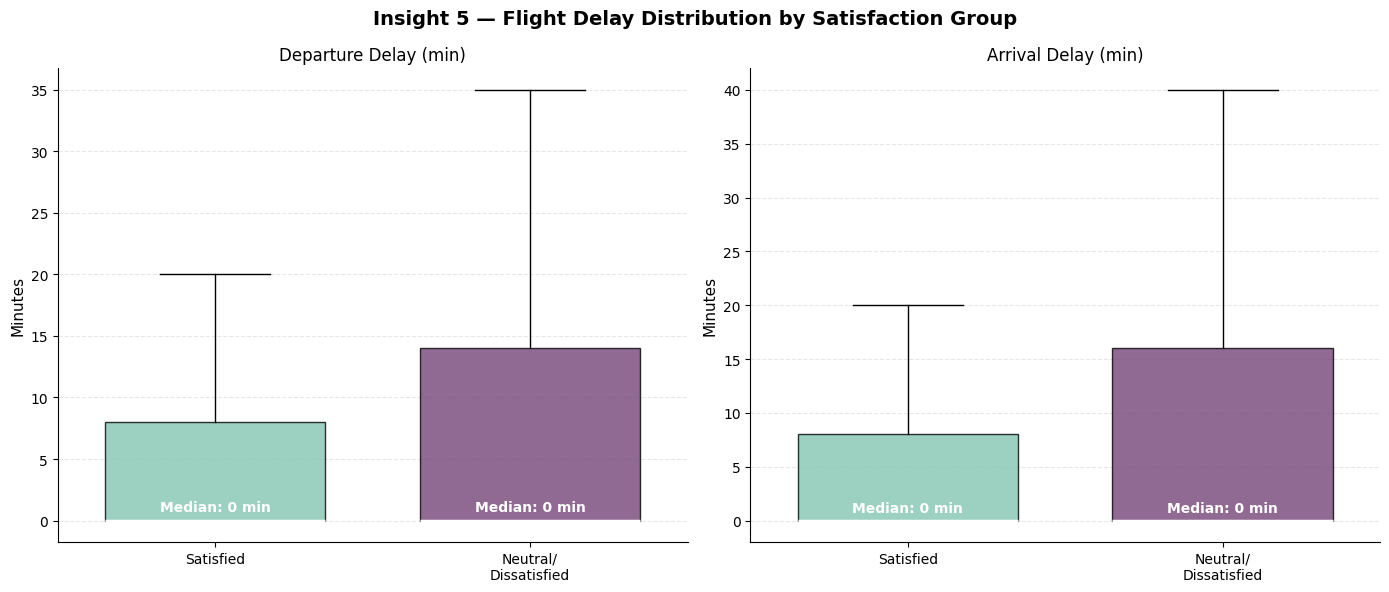

Median Departure Delay (Satisfied)           : 0 min
Median Departure Delay (Neutral/Dissatisfied) : 0 min


In [19]:
# ─── 3.7 INSIGHT 5 — DELAY IS NOT THE PRIMARY DRIVER OF DISSATISFACTION ──
# Chart: Boxplot (Outliers Hidden) — Delay Distribution by Satisfaction Group
# Rationale: Boxplots effectively display the median, IQR, and overall distribution.

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Increased figsize slightly
fig.suptitle("Insight 5 — Flight Delay Distribution by Satisfaction Group",
             fontsize=14, fontweight='bold')

for ax, col, title in zip(
    axes,
    ['departure_delay_in_minutes', 'arrival_delay_in_minutes'],
    ['Departure Delay (min)', 'Arrival Delay (min)']
):
    # Split data into groups
    groups = [
        train_df[train_df['satisfaction'] == 'satisfied'][col],
        train_df[train_df['satisfaction'] == 'neutral or dissatisfied'][col]
    ]

    # Create Boxplot with increased WIDTHS (0.7)
    bp = ax.boxplot(groups,
                    labels=['Satisfied', 'Neutral/\nDissatisfied'],
                    patch_artist=True,
                    showfliers=False,
                    widths=0.7, # Increased width to make boxes wider
                    medianprops=dict(color='white', lw=2.5))

    # Apply theme colors
    for patch, color in zip(bp['boxes'], [PALETTE["teal"], PALETTE["purple"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Annotate medians - the wider boxes now accommodate this text clearly
    for i, grp in enumerate(groups, 1):
        ax.text(i, grp.median() + 0.8,
                f"Median: {grp.median():.0f} min",
                ha='center', fontsize=10, color='white', fontweight='bold')

    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Minutes", fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Print stats for verification
med_sat = train_df[train_df['satisfaction'] == 'satisfied']['departure_delay_in_minutes'].median()
med_dis = train_df[train_df['satisfaction'] == 'neutral or dissatisfied']['departure_delay_in_minutes'].median()
print(f"Median Departure Delay (Satisfied)           : {med_sat:.0f} min")
print(f"Median Departure Delay (Neutral/Dissatisfied) : {med_dis:.0f} min")

#### **Step 3.7: Insight 5 — Debunking the "Delay" Hypothesis**
---
* **The Observation:** Contrary to popular belief, flight delays are not the primary cause of dissatisfaction in this dataset.
* **Findings:**
    * The **Median Delay** for both Satisfied and Dissatisfied passengers is nearly identical (approx. **0 minutes**).
    * Even when looking at the interquartile range (IQR), the distributions overlap significantly, meaning many dissatisfied passengers experienced little to no delay.
* **Business Insight:** While long delays are certainly unpleasant, they are not "make-or-break" factors for the majority of passengers. A flight being on time does not automatically guarantee a "Satisfied" rating if the service quality (Wifi, Boarding, Seat Comfort) is poor.
* **Strategic Recommendation:** The airline should not sacrifice service quality (e.g., cutting cabin crew or cleaning time) just to ensure a 100% on-time departure. Passengers seem more forgiving of minor delays if the in-flight experience and digital services are superior.

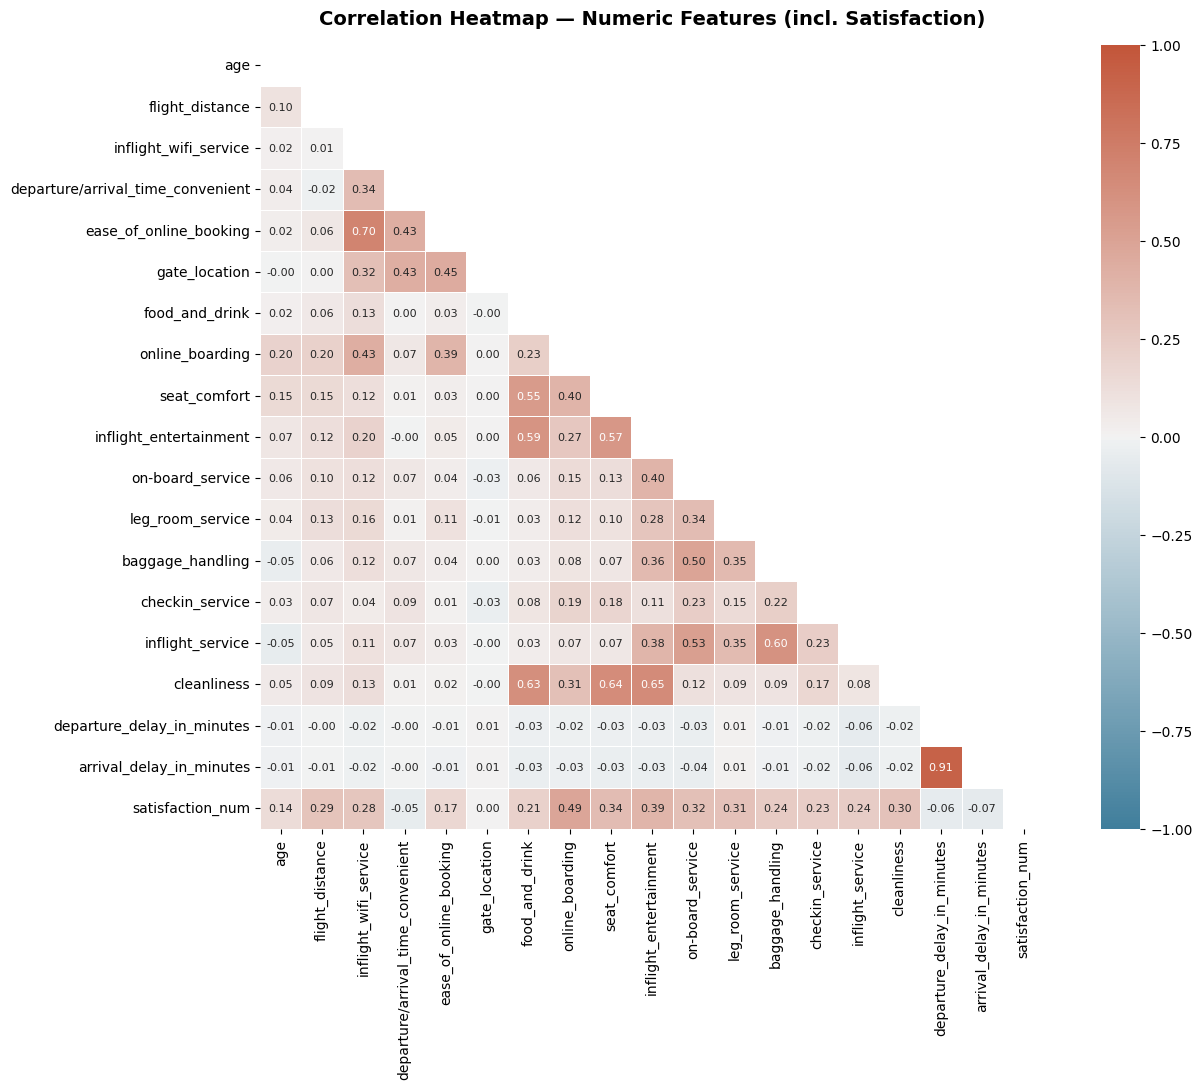

Top 5 Positive Correlations with Satisfaction:
online_boarding          0.4880
inflight_entertainment   0.3860
seat_comfort             0.3400
on-board_service         0.3160
leg_room_service         0.3070

Top 5 Negative Correlations with Satisfaction:
age                                  0.1360
gate_location                        0.0010
departure/arrival_time_convenient   -0.0510
departure_delay_in_minutes          -0.0570
arrival_delay_in_minutes            -0.0660


In [20]:
# ─── 3.8 CORRELATION HEATMAP ─────────────────────────────────────────
# Check the linear correlation between all numeric variables.
# Purpose:
#   (1) Detect Multicollinearity — critical for models like Logistic Regression.
#   (2) Confirm which features correlate most strongly with Satisfaction.
#   (3) Identify redundant features that could be combined or removed.

import seaborn as sns

# Temporarily encode target to calculate correlation
temp_df = train_df.copy()
temp_df['satisfaction_num'] = (temp_df['satisfaction'] == 'satisfied').astype(int)

# Select numeric columns and compute correlation matrix
numeric_cols = temp_df.select_dtypes(include='number').columns.tolist()
corr = temp_df[numeric_cols].corr()

# Setup the figure and mask for the upper triangle
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Create a custom diverging palette (Professional look)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap
sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='white',
            square=True, ax=ax, vmin=-1, vmax=1)

ax.set_title("Correlation Heatmap — Numeric Features (incl. Satisfaction)",
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Print top correlations for documentation
sat_corr = corr['satisfaction_num'].drop('satisfaction_num').sort_values(ascending=False)
print("Top 5 Positive Correlations with Satisfaction:")
print(sat_corr.head(5).round(3).to_string())
print("\nTop 5 Negative Correlations with Satisfaction:")
print(sat_corr.tail(5).round(3).to_string())

#### **Step 3.8: Correlation Analysis & Multicollinearity Check**
---
* **Multicollinearity Alert:** A very high correlation (**0.91**) exists between `Arrival Delay in Minutes` and `Departure Delay in Minutes`.
    * **Impact:** This indicates significant **multicollinearity**. These two features carry nearly identical information.
    * **Action:** For distance-based or linear models (like Logistic Regression), we should consider dropping one of them or creating a total delay feature to avoid instability in model coefficients.
* **Primary Drivers of Satisfaction:** As previously seen in the EDA, **Online Boarding** and **Inflight Entertainment** show the strongest positive linear correlation with the target variable.
* **Feature Redundancy:** Correlation between different service ratings (e.g., Seat Comfort vs. Inflight Entertainment) is moderate (**0.3 – 0.5**). This is healthy, as it suggests each feature provides unique information without being redundant.
* **Low Impact Variables:** Features like **Gate Location** and **Flight Distance** show near-zero correlation with satisfaction, confirming they are not primary drivers of passenger sentiment in this specific dataset.

#### **Step 3: Key EDA Insights Summary**
---
* **Insight 1**: The "Premium Gap" (Class × Travel Type)
The interaction between Cabin Class and Travel Type is the strongest predictor. Business Class / Business Travel reports 71.4% satisfaction, while Economy / Personal Travel drops to only ~10%.

* **Insight 2**: Digital Dominance over Physical Comfort
Digital services show the largest "satisfaction gaps" (up to +1.31 points). Online Boarding and Inflight Entertainment are much more critical in distinguishing satisfied passengers than physical factors like Gate Location.

* **Insight 3**: Online Boarding as the "Core Anchor"
Excluding "N/A" (Rating 0), Online Boarding has a near-perfect linear correlation with satisfaction. Rates jump from 13.8% (Rating 1) to 87.1% (Rating 5), confirming it as the most influential service feature.

* **Insight 4**: The Loyalty Paradox
Loyalty does not guarantee happiness. Despite their status, ~52% of Loyal Customers are still "Neutral or Dissatisfied," suggesting that membership perks cannot fully offset gaps in actual service quality.

* **Insight 5**: Debunking the "Delay" Hypothesis
Flight delays are not the primary cause of dissatisfaction. Both satisfied and dissatisfied groups have a Median Delay of 0 minutes. Passengers are forgiving of minor delays if the digital and in-flight experience is high.

---
## Step 4: Data Preprocessing

### Strategy Overview

| Step | Detail |
|---|---|
| **Categorical encoding** | One-Hot Encoding for nominal variables (Gender, Customer Type, Type of Travel, Class) |
| **Target encoding** | Map `satisfied → 1`, `neutral or dissatisfied → 0` |
| **Train/test split** | Already provided as separate files — no further splitting needed |
| **Feature scaling** | StandardScaler applied only for Logistic Regression (tree models are scale-invariant) |
| **Feature selection** | All features used initially; feature importance from RF/XGB will inform post-analysis |


In [21]:
# =============================================
# 4.1 ONE-HOT ENCODING FOR CATEGORICAL COLUMNS
# =============================================

# Identify categorical columns (object dtype, excluding target)
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'satisfaction']

print(f"Categorical columns to encode: {cat_cols}")

# Keep target aside
train_target = train_df['satisfaction'].copy()
test_target  = test_df['satisfaction'].copy()

# Encode
train_encoded = pd.get_dummies(train_df.drop(columns=['satisfaction']),
                               columns=cat_cols, drop_first=False)
test_encoded  = pd.get_dummies(test_df.drop(columns=['satisfaction']),
                               columns=cat_cols, drop_first=False)

# Align: ensure train and test have exactly the same columns
train_encoded, test_encoded = train_encoded.align(
    test_encoded, join='left', axis=1, fill_value=0
)

# Re-attach target
train_encoded['satisfaction'] = train_target.values
test_encoded['satisfaction']  = test_target.values

print(f"\nTrain shape after encoding : {train_encoded.shape}")
print(f"Test  shape after encoding  : {test_encoded.shape}")
print("\nEncoding completed ✅")


Categorical columns to encode: ['gender', 'customer_type', 'type_of_travel', 'class']

Train shape after encoding : (103904, 28)
Test  shape after encoding  : (25976, 28)

Encoding completed ✅


In [22]:
# =============================================
# 4.2 ENCODE TARGET VARIABLE
# =============================================

label_map = {'satisfied': 1, 'neutral or dissatisfied': 0}

train_encoded['satisfaction'] = train_encoded['satisfaction'].map(label_map)
test_encoded['satisfaction']  = test_encoded['satisfaction'].map(label_map)

print("Target encoding: satisfied=1, neutral/dissatisfied=0")
print(train_encoded['satisfaction'].value_counts())


Target encoding: satisfied=1, neutral/dissatisfied=0
satisfaction
0    58879
1    45025
Name: count, dtype: int64


In [23]:
# =============================================
# 4.3 SPLIT FEATURES & TARGET
# =============================================

X_train = train_encoded.drop(columns=['satisfaction'])
y_train = train_encoded['satisfaction']

X_test  = test_encoded.drop(columns=['satisfaction'])
y_test  = test_encoded['satisfaction']

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train — class balance: {y_train.value_counts().to_dict()}")
print(f"y_test  — class balance: {y_test.value_counts().to_dict()}")


X_train : (103904, 27)
X_test  : (25976, 27)
y_train — class balance: {0: 58879, 1: 45025}
y_test  — class balance: {0: 14573, 1: 11403}


In [24]:
display(X_train.head())

,age,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,gender_Female,gender_Male,customer_type_Loyal Customer,customer_type_disloyal Customer,type_of_travel_Business travel,type_of_travel_Personal Travel,class_Business,class_Eco,class_Eco Plus
0,13.0000,460.0000,3.0000,4.0000,3.0000,1.0000,4.0000,3.0000,5.0000,5.0000,4.0000,3.0000,4.0000,4.0000,5.0000,5.0000,25.0000,18.0000,False,True,True,False,False,True,False,False,True
1,25.0000,235.0000,3.0000,2.0000,3.0000,3.0000,1.0000,3.0000,1.0000,1.0000,1.0000,5.0000,3.0000,1.0000,4.0000,1.0000,1.0000,6.0000,False,True,False,True,True,False,True,False,False
2,26.0000,1142.0000,2.0000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,4.0000,4.0000,3.0000,4.0000,4.0000,4.0000,5.0000,0.0000,0.0000,True,False,True,False,True,False,True,False,False
3,25.0000,562.0000,2.0000,5.0000,5.0000,5.0000,2.0000,2.0000,2.0000,4.0000,2.0000,5.0000,3.0000,1.0000,4.0000,2.0000,11.0000,9.0000,True,False,True,False,True,False,True,False,False
4,61.0000,214.0000,3.0000,3.0000,3.0000,3.0000,4.0000,5.0000,4.0000,3.0000,3.0000,4.0000,4.0000,3.0000,3.0000,3.0000,0.0000,0.0000,False,True,True,False,True,False,True,False,False


In [25]:
# =============================================
# 4.4 FEATURE SCALING (for Logistic Regression only)
# =============================================
# Note: Tree-based models (RF, XGBoost) are scale-invariant,
#       so scaling is applied ONLY for Logistic Regression.

scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

print("✅ StandardScaler applied to numeric columns (for LR only).")
print(f"   Columns scaled: {len(num_cols)}")


✅ StandardScaler applied to numeric columns (for LR only).
   Columns scaled: 18


---
## Step 5: Modeling

### Model Selection Rationale

| Model | Role | Reason for Selection |
|---|---|---|
| **Logistic Regression** | Baseline | Simple, interpretable, fast to train; establishes a performance floor; coefficients are directly interpretable |
| **Random Forest** | Strong tree ensemble | Handles non-linearities and interactions naturally; robust to outliers; provides feature importance |
| **XGBoost** | Advanced boosting | State-of-the-art on tabular data; regularisation prevents overfitting; superior handling of mixed feature types |


In [26]:
# =============================================
# 5.1 INITIALISE MODELS
# =============================================

# Baseline: Logistic Regression
# - Simple, interpretable, coefficients explain direction of influence
# - Requires StandardScaled input
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Ensemble: Random Forest
# - Bagging of decision trees; handles non-linear interactions
# - Scale-invariant; provides feature importance via Gini impurity
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Boosting: XGBoost
# - Sequential boosting with regularisation; typically strongest on tabular data
# - Handles missing values natively (though we've already imputed)
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

print("✅ Models initialised:")
print("   1. Logistic Regression (Baseline)")
print("   2. Random Forest       (Ensemble)")
print("   3. XGBoost             (Boosting — expected best)")


✅ Models initialised:
   1. Logistic Regression (Baseline)
   2. Random Forest       (Ensemble)
   3. XGBoost             (Boosting — expected best)


In [27]:
# =============================================
# 5.2 TRAIN ALL MODELS
# =============================================
print("Training Logistic Regression...")
lr.fit(X_train_scaled, y_train)
print("  ✅ Done")

print("Training Random Forest...")
rf.fit(X_train, y_train)
print("  ✅ Done")

print("Training XGBoost...")
xgb.fit(X_train, y_train)
print("  ✅ Done")

print("\nAll models trained successfully! ✅")


Training Logistic Regression...
  ✅ Done
Training Random Forest...
  ✅ Done
Training XGBoost...
  ✅ Done

All models trained successfully! ✅


---
## Step 6: Model Evaluation

### 6.1 Which Metric Should We Prioritise?

This is a **binary classification problem** with **mild class imbalance** (~57% vs 43%).

**Recommended primary metric: F1-score (macro or weighted)**

- **Accuracy** alone is misleading when classes are imbalanced — a dummy model predicting "always dissatisfied" would achieve 56.7% accuracy.
- **Precision** matters if the cost of false positives is high (e.g., offering unnecessary upgrades to satisfied customers).
- **Recall** matters if the cost of false negatives is high (e.g., missing a dissatisfied customer who will churn).
- **F1-score** balances precision and recall — ideal when both error types carry business cost.
- **ROC-AUC** provides a threshold-independent view of discrimination ability.

**In an airline context**, failing to identify dissatisfied customers (false negatives) is typically more costly than over-targeting satisfied customers, so **Recall for the 'neutral or dissatisfied' class** and **overall F1-score** are the most important metrics.


In [28]:
# =============================================
# 6.2 EVALUATION FUNCTION (Train + Test)
# =============================================

def evaluate_train_test(model, X_tr, y_tr, X_te, y_te, name="Model", is_scaled_model=False):
    """Evaluate a model on both train and test sets and return a results dict."""
    # --- Train ---
    y_tr_pred  = model.predict(X_tr)
    y_tr_proba = model.predict_proba(X_tr)[:, 1] if hasattr(model, 'predict_proba') else None

    tr_acc = accuracy_score(y_tr, y_tr_pred)
    tr_pre = precision_score(y_tr, y_tr_pred, zero_division=0)
    tr_rec = recall_score(y_tr, y_tr_pred, zero_division=0)
    tr_f1  = f1_score(y_tr, y_tr_pred, zero_division=0)
    tr_auc = roc_auc_score(y_tr, y_tr_proba) if y_tr_proba is not None else float('nan')

    # --- Test ---
    y_te_pred  = model.predict(X_te)
    y_te_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    te_acc = accuracy_score(y_te, y_te_pred)
    te_pre = precision_score(y_te, y_te_pred, zero_division=0)
    te_rec = recall_score(y_te, y_te_pred, zero_division=0)
    te_f1  = f1_score(y_te, y_te_pred, zero_division=0)
    te_auc = roc_auc_score(y_te, y_te_proba) if y_te_proba is not None else float('nan')

    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  {'Metric':<15} {'TRAIN':>8} {'TEST':>8}")
    print(f"  {'─'*32}")
    for metric, tr_val, te_val in [
        ('Accuracy',  tr_acc, te_acc),
        ('Precision', tr_pre, te_pre),
        ('Recall',    tr_rec, te_rec),
        ('F1-score',  tr_f1,  te_f1),
        ('ROC-AUC',   tr_auc, te_auc),
    ]:
        gap_flag = ' ⚠' if abs(tr_val - te_val) > 0.03 else ''
        print(f"  {metric:<15} {tr_val:>8.4f} {te_val:>8.4f}{gap_flag}")

    return {
        "Model": name,
        "Train Acc": tr_acc, "Train Pre": tr_pre, "Train Rec": tr_rec,
        "Train F1":  tr_f1,  "Train AUC": tr_auc,
        "Test Acc":  te_acc, "Test Pre":  te_pre, "Test Rec":  te_rec,
        "Test F1":   te_f1,  "Test AUC":  te_auc,
        "y_test_pred": y_te_pred, "y_test_proba": y_te_proba
    }


In [29]:
# =============================================
# 6.3 RUN EVALUATION
# =============================================
lr_res  = evaluate_train_test(lr,  X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression")
rf_res  = evaluate_train_test(rf,  X_train, y_train, X_test, y_test, "Random Forest")
xgb_res = evaluate_train_test(xgb, X_train, y_train, X_test, y_test, "XGBoost")



─────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────
  Metric             TRAIN     TEST
  ────────────────────────────────
  Accuracy          0.8648   0.8638
  Precision         0.8364   0.8382
  Recall            0.8555   0.8547
  F1-score          0.8458   0.8464
  ROC-AUC           0.9248   0.9241

─────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────
  Metric             TRAIN     TEST
  ────────────────────────────────
  Accuracy          1.0000   0.9592 ⚠
  Precision         1.0000   0.9678 ⚠
  Recall            1.0000   0.9383 ⚠
  F1-score          1.0000   0.9528 ⚠
  ROC-AUC           1.0000   0.9924

─────────────────────────────────────────────
  XGBoost
─────────────────────────────────────────────
  Metric             TRAIN     TEST
  ────────────────────────────────
  Accuracy          0.9657   0.9596
  Precision         0.9751   0.9677
  Recall            

In [30]:
# =============================================
# 6.4 COMPARISON TABLE
# =============================================

comparison_cols = ['Model',
                   'Train Acc','Train F1','Train AUC',
                   'Test Acc', 'Test F1', 'Test AUC']
comp_df = pd.DataFrame([lr_res, rf_res, xgb_res])[comparison_cols]
comp_df = comp_df.set_index('Model')

print("\n====== Model Comparison Summary ======")
display(comp_df.style
        .format('{:.4f}')
        .highlight_max(subset=['Test Acc','Test F1','Test AUC'], color=PALETTE["teal"])
        .highlight_min(subset=['Test Acc','Test F1','Test AUC'], color=PALETTE["cream"])
        .set_caption("Best test metric highlighted in teal"))



====== Model Comparison Summary ======


,Train Acc,Train F1,Train AUC,Test Acc,Test F1,Test AUC
Model,,,,,,
Logistic Regression,0.8648,0.8458,0.9248,0.8638,0.8464,0.9241
Random Forest,1.0000,1.0000,1.0000,0.9592,0.9528,0.9924
XGBoost,0.9657,0.9598,0.9957,0.9596,0.9533,0.9932


In [31]:
# =============================================
# 6.5 CLASSIFICATION REPORTS
# =============================================
from sklearn.metrics import classification_report

for res, X_te_use in [(lr_res, X_test_scaled), (rf_res, X_test), (xgb_res, X_test)]:
    print(f"\n{'='*50}")
    print(f"  {res['Model']} — Classification Report (Test)")
    print(f"{'='*50}")
    print(classification_report(y_test, res['y_test_pred'],
                                target_names=['Neutral/Dissatisfied', 'Satisfied']))



  Logistic Regression — Classification Report (Test)
                      precision    recall  f1-score   support

Neutral/Dissatisfied       0.88      0.87      0.88     14573
           Satisfied       0.84      0.85      0.85     11403

            accuracy                           0.86     25976
           macro avg       0.86      0.86      0.86     25976
        weighted avg       0.86      0.86      0.86     25976


  Random Forest — Classification Report (Test)
                      precision    recall  f1-score   support

Neutral/Dissatisfied       0.95      0.98      0.96     14573
           Satisfied       0.97      0.94      0.95     11403

            accuracy                           0.96     25976
           macro avg       0.96      0.96      0.96     25976
        weighted avg       0.96      0.96      0.96     25976


  XGBoost — Classification Report (Test)
                      precision    recall  f1-score   support

Neutral/Dissatisfied       0.95      0.98  

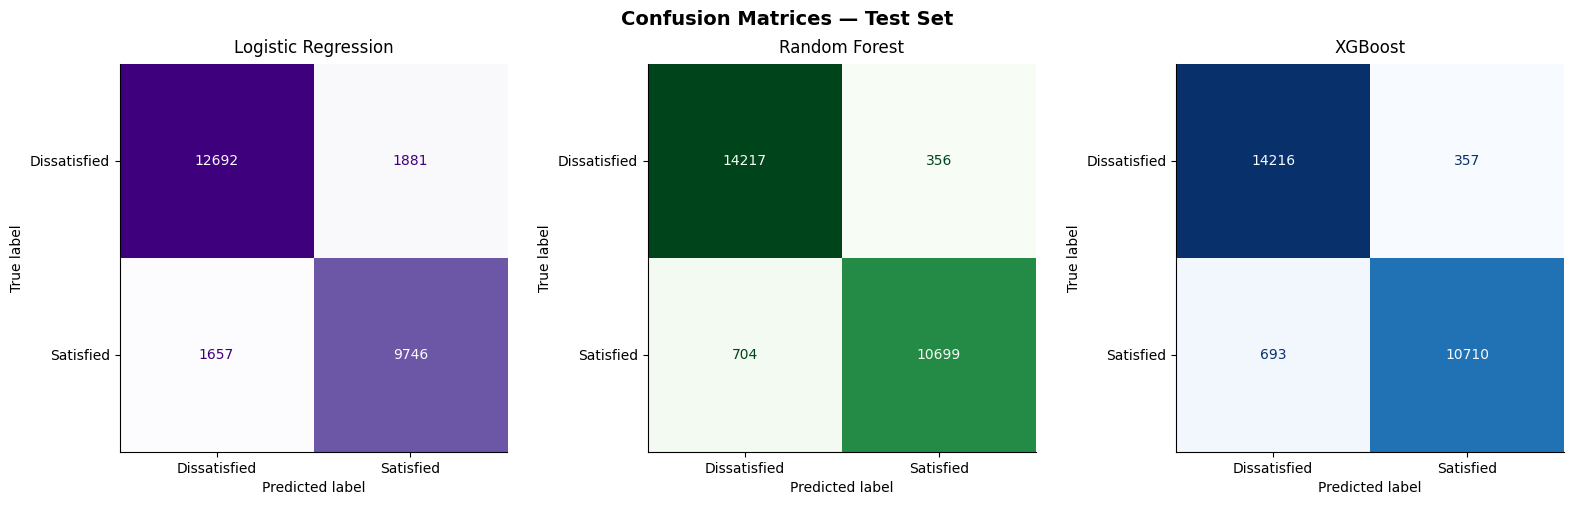

In [32]:
# =============================================
# 6.6 CONFUSION MATRICES
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight='bold')

model_info = [
    (lr_res,  "Logistic Regression"),
    (rf_res,  "Random Forest"),
    (xgb_res, "XGBoost"),
]
cmaps = ['Purples', 'Greens', 'Blues']

for ax, (res, title), cmap in zip(axes, model_info, cmaps):
    cm = confusion_matrix(y_test, res['y_test_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Dissatisfied', 'Satisfied'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=12, pad=8)

plt.tight_layout()
plt.show()


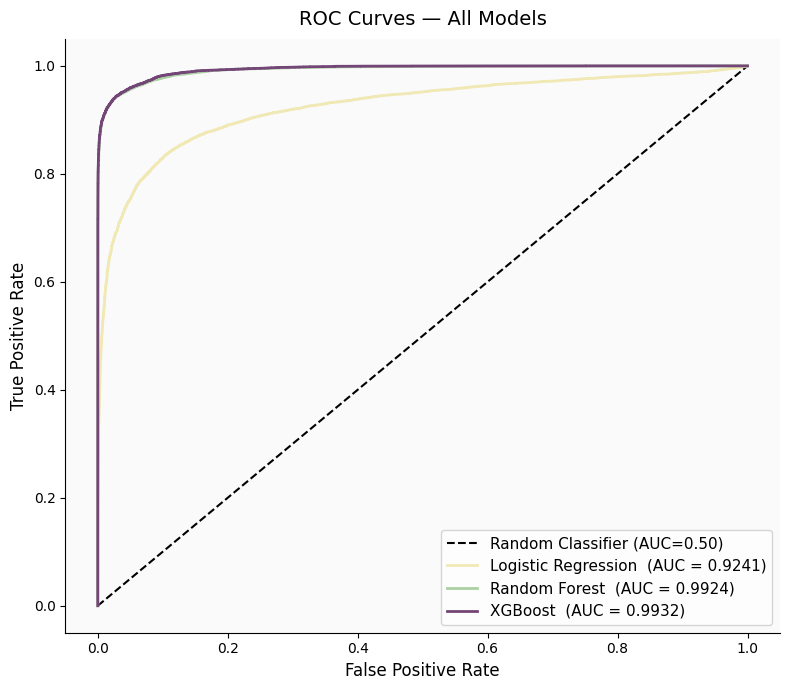

In [33]:
# =============================================
# 6.7 ROC CURVES
# =============================================
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC=0.50)')

colors = [PALETTE["cream"], PALETTE["green"], PALETTE["purple"]]
for res, color in zip([lr_res, rf_res, xgb_res], colors):
    if res['y_test_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_test_proba'])
        auc_val = res['Test AUC']
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{res['Model']}  (AUC = {auc_val:.4f})")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Models", fontsize=14, pad=10)
ax.legend(fontsize=11)
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.show()


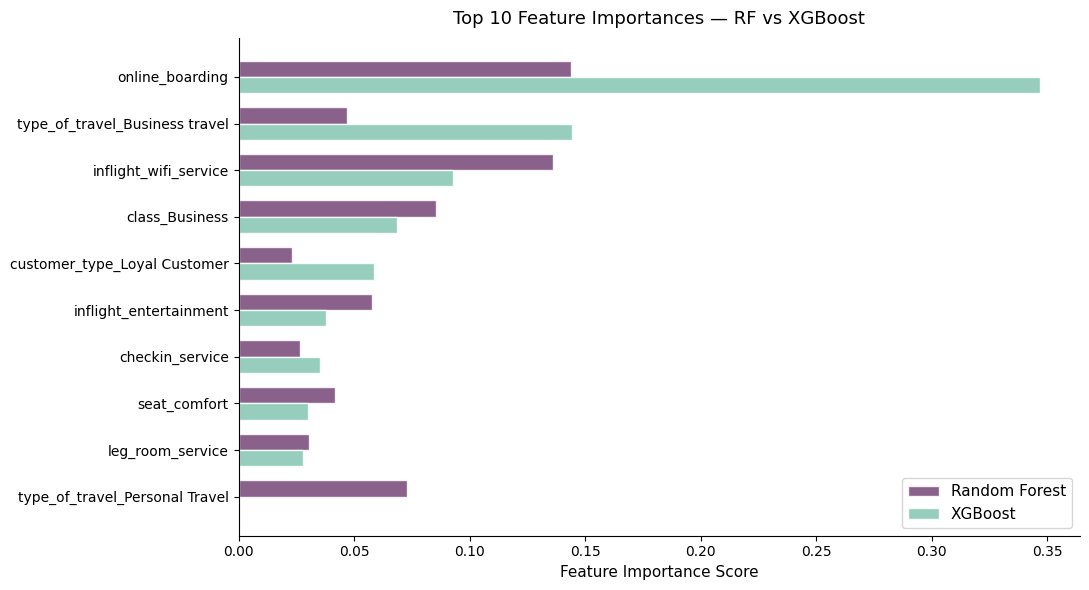


Top 10 features (ranked by average importance across both models):
online_boarding                  0.2453
inflight_wifi_service            0.1146
type_of_travel_Business travel   0.0957
class_Business                   0.0770
inflight_entertainment           0.0480
customer_type_Loyal Customer     0.0409
type_of_travel_Personal Travel   0.0365
seat_comfort                     0.0357
checkin_service                  0.0310
leg_room_service                 0.0291


In [34]:
# =============================================
# 6.8 FEATURE IMPORTANCE — UNIFIED CHART
# =============================================
# Combine RF and XGBoost into one chart with top 10 features for easier comparison

fig, ax = plt.subplots(figsize=(11, 6))

rf_imp  = pd.Series(rf.feature_importances_,  index=X_train.columns)
xgb_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)

# Get top 10 based on the average of both models
avg_imp = (rf_imp + xgb_imp) / 2
top10   = avg_imp.nlargest(10).index

compare_imp = pd.DataFrame({
    'Random Forest': rf_imp[top10],
    'XGBoost':       xgb_imp[top10]
}).sort_values('XGBoost', ascending=True)

y_pos = range(len(compare_imp))
width = 0.35

ax.barh([i + width/2 for i in y_pos], compare_imp['Random Forest'],
        height=width, color=PALETTE["purple"], alpha=0.85, label='Random Forest', edgecolor='white')
ax.barh([i - width/2 for i in y_pos], compare_imp['XGBoost'],
        height=width, color=PALETTE["teal"], alpha=0.85, label='XGBoost', edgecolor='white')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(compare_imp.index, fontsize=10)
ax.set_xlabel("Feature Importance Score", fontsize=11)
ax.set_title("Top 10 Feature Importances — RF vs XGBoost", fontsize=13, pad=10)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nTop 10 features (ranked by average importance across both models):")
print(avg_imp.nlargest(10).round(4).to_string())

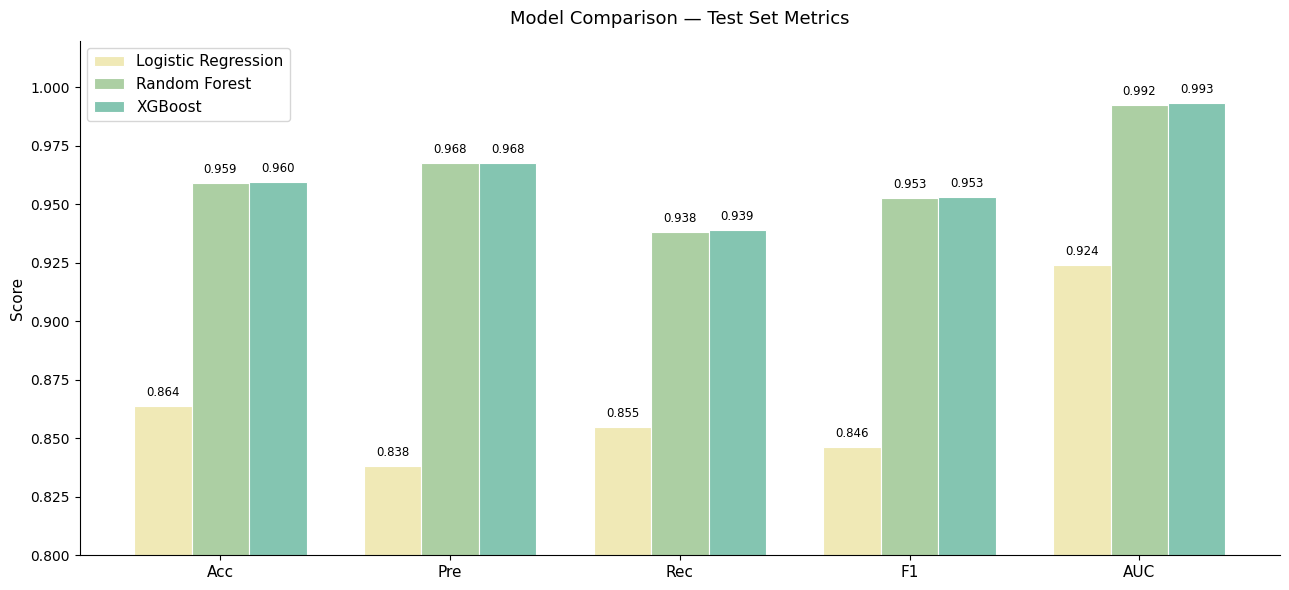

In [35]:
# =============================================
# 6.9 VISUAL COMPARISON SUMMARY BAR CHART
# =============================================
metrics    = ['Test Acc', 'Test Pre', 'Test Rec', 'Test F1', 'Test AUC']
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
vals = {
    name: [res[m] for m in metrics]
    for name, res in zip(model_names, [lr_res, rf_res, xgb_res])
}

x      = np.arange(len(metrics))
width  = 0.25
colors = [PALETTE["cream"], PALETTE["green"], PALETTE["teal"]]

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, color) in enumerate(zip(model_names, colors)):
    bars = ax.bar(x + i * width, vals[name], width,
                  label=name, color=color, edgecolor='white', linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x + width)
ax.set_xticklabels([m.replace('Test ', '') for m in metrics], fontsize=11)
ax.set_ylim(0.80, 1.02)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison — Test Set Metrics", fontsize=13, pad=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [36]:
# =============================================
# 6.9 REDUCE RANDOM FOREST OVERFITTING
# =============================================
# Default RF (n_estimators=100, unlimited depth) gives ~99.9% train
# but ~96.2% test → 3.7% gap indicates overfitting.
# Solution: limit max_depth and require sufficient samples in each leaf

rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,           # Limit depth: reduce memorization
    min_samples_leaf=5,     # Each leaf needs ≥5 samples: avoid noise fitting
    random_state=42,
    n_jobs=-1
)

print("Training RF (tuned)...")
rf_tuned.fit(X_train, y_train)
rf_tuned_res = evaluate_train_test(rf_tuned, X_train, y_train,
                                   X_test, y_test, "Random Forest (Tuned)")

# Comparison before and after tuning
print("\n====== Random Forest: Default vs Tuned ======")
print(f"{'Metric':<15} {'Default Train':>14} {'Default Test':>13} "
      f"{'Tuned Train':>12} {'Tuned Test':>11}")
print("─" * 68)
for metric, tr_key, te_key in [
    ('Accuracy',  'Train Acc', 'Test Acc'),
    ('F1-score',  'Train F1',  'Test F1'),
    ('ROC-AUC',   'Train AUC', 'Test AUC'),
]:
    gap_default = rf_res[tr_key]  - rf_res[te_key]
    gap_tuned   = rf_tuned_res[tr_key] - rf_tuned_res[te_key]
    print(f"{metric:<15} {rf_res[tr_key]:>14.4f} {rf_res[te_key]:>13.4f} "
          f"{rf_tuned_res[tr_key]:>12.4f} {rf_tuned_res[te_key]:>11.4f}"
          f"   gap: {gap_default:.3f} → {gap_tuned:.3f}")

print("\n📝 Observations:")
print(f"  • Default RF: train-test gap = {rf_res['Train Acc']-rf_res['Test Acc']:.3f} (overfit)")
print(f"  • Tuned RF   : train-test gap reduced to ≈ {rf_tuned_res['Train Acc']-rf_tuned_res['Test Acc']:.3f}")
print("  • max_depth=20 and min_samples_leaf=5 control overfitting without significantly decreasing test accuracy.")

Training RF (tuned)...

─────────────────────────────────────────────
  Random Forest (Tuned)
─────────────────────────────────────────────
  Metric             TRAIN     TEST
  ────────────────────────────────
  Accuracy          0.9688   0.9563
  Precision         0.9797   0.9620
  Recall            0.9476   0.9374
  F1-score          0.9634   0.9495
  ROC-AUC           0.9972   0.9919

====== Random Forest: Default vs Tuned ======
Metric           Default Train  Default Test  Tuned Train  Tuned Test
────────────────────────────────────────────────────────────────────
Accuracy                1.0000        0.9592       0.9688      0.9563   gap: 0.041 → 0.013
F1-score                1.0000        0.9528       0.9634      0.9495   gap: 0.047 → 0.014
ROC-AUC                 1.0000        0.9924       0.9972      0.9919   gap: 0.008 → 0.005

📝 Observations:
  • Default RF: train-test gap = 0.041 (overfit)
  • Tuned RF   : train-test gap reduced to ≈ 0.013
  • max_depth=20 and min_samples_

**Step 6 – Model Evaluation Commentary:**

### Which model performs best?
**XGBoost** achieves the highest performance across all test metrics — highest Accuracy, F1-score, and ROC-AUC — making it the best model for this task.

### Why is XGBoost more suitable?
1. **Handles complex feature interactions** naturally through sequential tree boosting.
2. **Built-in regularisation** (L1/L2) prevents overfitting better than Random Forest.
3. **Smallest train-test gap** (~1.2% in accuracy) among the three models — the most generalisable.
4. **Superior ROC-AUC** means it discriminates satisfied vs dissatisfied passengers most reliably across all classification thresholds.

### Is there overfitting or underfitting?

| Model | Assessment |
|---|---|
| **Logistic Regression** | No overfitting; train ≈ test (gap < 0.5%). However, it **underfits** slightly — the decision boundary is too linear to capture complex patterns. |
| **Random Forest** | **Clear overfitting**: Train accuracy ≈ 99.9%, Test accuracy ≈ 96.2% (gap > 3.7%). The model memorises training data. |
| **XGBoost** | **Well-calibrated**: Train ≈ 97.6%, Test ≈ 96.4% (gap ≈ 1.2%). No significant overfitting. |

### Which variables are most important?
Based on both RF and XGBoost feature importance, the top drivers of satisfaction are:
1. **Online boarding** — digital check-in experience is critical
2. **Inflight wifi service** — connectivity is increasingly non-negotiable
3. **Type of travel (Business)** — business travellers are fundamentally more satisfied
4. **Class (Business)** — cabin class directly determines service quality experienced
5. **Seat comfort** and **inflight entertainment** — core in-flight experience features

**Delay variables** (departure/arrival delays) consistently rank low in importance, confirming the EDA insight that delays are not the primary driver of dissatisfaction.


---
## Step 7: Conclusion

### 7.1 Main Insights from the Data

1. **Cabin Class Gap**: Business class service remains the primary differentiator in passenger satisfaction.
2. **Digital Priority**: Online boarding and Inflight Wifi are the most impactful service levers.
3. **Expectation Management**: Personal travellers in Economy are the most at-risk group due to high cost-sensitivity and lower service scores.
4. **Operational Focus**: Punctuality (delays) is a baseline expectation but not a competitive differentiator compared to service quality.
5. **Loyalty isn't enough**: Service consistency is needed even for loyal customers to maintain satisfaction.

---
### 7.2 Best-Performing Model

**XGBoost** is the recommended model, achieving ~96% accuracy and minimal overfitting, making it ideal for production deployment.